## arXiv corpus — read this first

This is the **arXiv** twin of the S2ORC notebook, generated by
`accelscan.scripts.make_arxiv_notebooks`. Edit the S2ORC original and regenerate.

Four things make arXiv levels **not** comparable to S2ORC levels:

1. **Self-selected preprints**, skewed to physics and CS, with no peer-review filter.
2. **Raw-LaTeX matching.** The matcher reads the `.tex` source, which includes figure
   captions, spec tables, code listings and `%` comments that GROBID drops from
   S2ORC. This biases any-mention prevalence *upward*; `reported use` and
   model-specific series are better protected because the LLM judges the passage.
3. **No citations.** There is no arXiv→corpusid crosswalk, so §6.4-style citation
   analyses are absent here.
4. **1991–2026 available, 2005–2026 analysed.** 2026 is a partial calendar year:
   fine for shares, marked on counts.

Only **within-corpus trends** should be compared across the two corpora.


# GPU usage by year and field

Exploratory analysis of stage-2 accelerator mentions: NVIDIA vs AMD and
NVIDIA model composition, over time and across fields. Reads whatever mention
shards are on S3 (partial or full).

**Kernel:** run with **Python (accelscan)**. Launch Jupyter from a shell where
the S3 creds are exported (`set -a; source .env; set +a`) so `storage_options`
can reach the MSI bucket.

**Partial-data caveat:** `repack` sorts passages by `corpusid`, which is roughly
chronological, so early shards skew toward *older* papers. Until all 36 shards
land, recent years and modern datacenter GPUs (A100/H100/4090) are
under-represented — rerun once the full run finishes.

In [1]:
import os
while not os.path.isdir('registry') and os.getcwd() != '/':
    os.chdir('..')


%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from accelscan.config import BUCKET, OUT_PREFIX
from accelscan.normalize import canonicalize_column
from accelscan.registry import load_registry
from accelscan.s3 import storage_options
from accelscan.plotting import setup_figures
from accelscan.meta import paper_fields
from accelscan.paths import (analytic_base, candidates_root, capacity_key,
                             get_corpus, precision_key, s3_uri)

# integer year ticks + every figure exported to output/analysis/gpu_usage/
setup_figures('arxiv/gpu_usage')

## Global knobs

In [2]:
# Which mention usage contexts to count. A list drawn from:
#   'used-in-this-work', 'comparison-or-related-work',
#   'object-of-study', 'speculative-future'; or None for all contexts.
USAGE_CONTEXTS: list[str] | None = ['used-in-this-work']

MODEL_TAG = 'qwen3-14b'
PROMPT_VERSION = 'p1'
YEAR_MIN, YEAR_MAX = 2005, 2026
TOP_MODELS = 20
TOP_FIELDS = 20

# Okabe-Ito colorblind-safe categorical palette; brand-thematic for the 2-way plot
PALETTE = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#E69F00',
           '#56B4E9', '#F0E442', '#999999', '#000000', '#984EA3']
MFR_COLOR = {'nvidia': '#76B900', 'amd': '#ED1C24'}

## Load and enrich mentions

Status-`ok`, usage-filtered, canonicalized against the registry, joined to paper year and primary field.

In [3]:
reg = load_registry()
so = storage_options()
CORPUS = 'arxiv'
c = get_corpus(CORPUS); KEY = c.key      # 'paper_id'; corpusid is null for arXiv


def mentions_glob():
    from accelscan.s3 import mentions_glob as _mg
    return _mg(MODEL_TAG, PROMPT_VERSION, corpus=c)

def load_enriched(usage_contexts):
    m = (pl.scan_parquet(mentions_glob(), storage_options=so)
         .filter(pl.col('status') == 'ok')
         .select(KEY, 'model_normalized', 'manufacturer',
                 'accelerator_subtype', 'usage_context')
         .collect())
    if usage_contexts is not None:
        m = m.filter(pl.col('usage_context').is_in(usage_contexts))
    m = canonicalize_column(m, reg)
    ids = m.select(KEY).unique().to_series().to_list()
    papers = paper_fields(c, pl.DataFrame({KEY: ids}), so).select(KEY, 'year',
                                                                'field')
    return m.join(papers, on=KEY, how='left')

def distinct_paper_counts(df, group_cols):
    """Distinct papers per group (a model mentioned many times in one paper
    counts once)."""
    return (df.select(group_cols + [KEY]).unique()
            .group_by(group_cols).agg(papers=pl.len()))

def top_nvidia_models(df):
    d = df.filter((pl.col('manufacturer') == 'nvidia')
                  & (pl.col('canonical_kind') == 'model')
                  & pl.col('canonical_display').is_not_null())
    return (distinct_paper_counts(d, ['canonical_display'])
            .sort('papers', descending=True).head(TOP_MODELS)['canonical_display'].to_list())

USAGE_LABEL = 'all usage contexts' if USAGE_CONTEXTS is None else ', '.join(USAGE_CONTEXTS)
df = load_enriched(USAGE_CONTEXTS)
print(f'{df.height} mentions | {df.n_unique(KEY)} papers | usage = {USAGE_LABEL}')

525637 mentions | 235481 papers | usage = used-in-this-work


## NVIDIA vs AMD by year

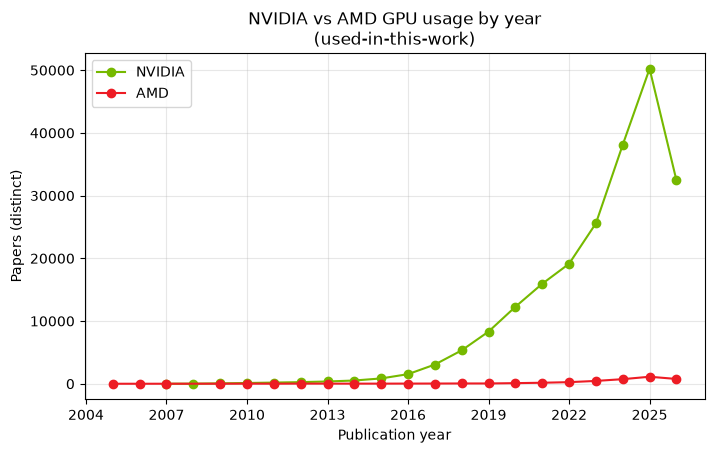

In [4]:
d = df.filter(pl.col('manufacturer').is_in(['nvidia', 'amd'])
              & pl.col('year').is_between(YEAR_MIN, YEAR_MAX))
counts = distinct_paper_counts(d, ['manufacturer', 'year'])
fig, ax = plt.subplots(figsize=(8, 4.5))
for mfr in ['nvidia', 'amd']:
    s = counts.filter(pl.col('manufacturer') == mfr).sort('year')
    ax.plot(s['year'], s['papers'], marker='o', label=mfr.upper(), color=MFR_COLOR[mfr])
ax.set(xlabel='Publication year', ylabel='Papers (distinct)',
       title=f'NVIDIA vs AMD GPU usage by year\n({USAGE_LABEL})')
ax.legend(); ax.grid(alpha=0.3); plt.show()

## NVIDIA vs AMD by field

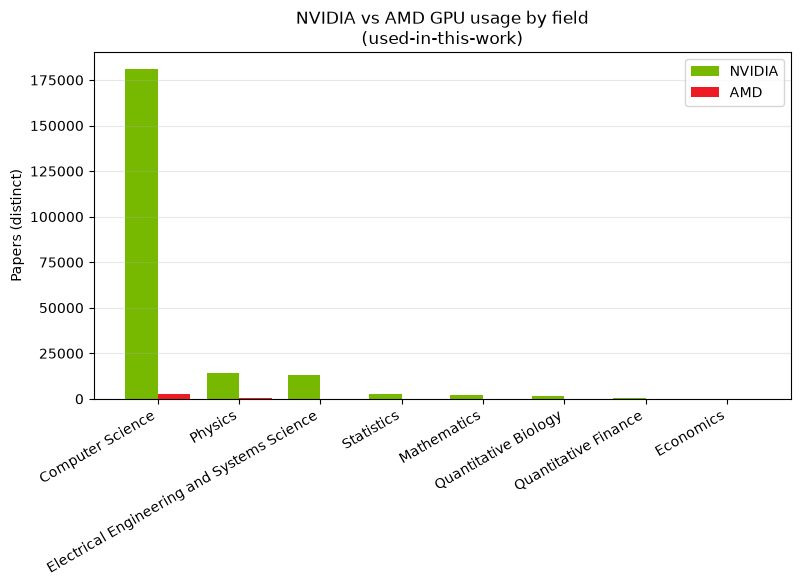

In [5]:
d = df.filter(pl.col('manufacturer').is_in(['nvidia', 'amd']) & pl.col('field').is_not_null())
counts = distinct_paper_counts(d, ['manufacturer', 'field'])
top = (counts.group_by('field').agg(t=pl.col('papers').sum())
       .sort('t', descending=True).head(TOP_FIELDS)['field'].to_list())
counts = counts.filter(pl.col('field').is_in(top))
wide = {mfr: {r['field']: r['papers'] for r in
              counts.filter(pl.col('manufacturer') == mfr).iter_rows(named=True)}
        for mfr in ['nvidia', 'amd']}
x = np.arange(len(top)); w = 0.4
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x - w/2, [wide['nvidia'].get(f, 0) for f in top], w, label='NVIDIA', color=MFR_COLOR['nvidia'])
ax.bar(x + w/2, [wide['amd'].get(f, 0) for f in top], w, label='AMD', color=MFR_COLOR['amd'])
ax.set_xticks(x); ax.set_xticklabels(top, rotation=30, ha='right')
ax.set(ylabel='Papers (distinct)', title=f'NVIDIA vs AMD GPU usage by field\n({USAGE_LABEL})')
ax.legend(); ax.grid(alpha=0.3, axis='y'); plt.show()

## NVIDIA models by year

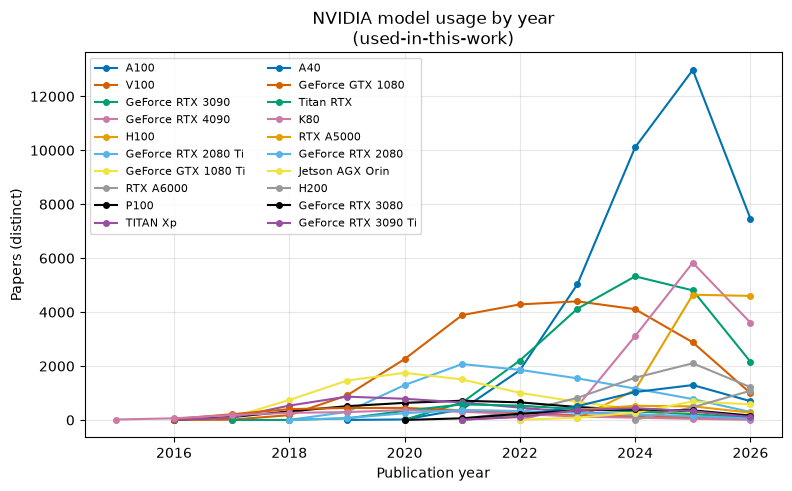

In [6]:
top = top_nvidia_models(df)
d = df.filter(pl.col('canonical_display').is_in(top) & pl.col('year').is_between(YEAR_MIN, YEAR_MAX))
counts = distinct_paper_counts(d, ['canonical_display', 'year'])
fig, ax = plt.subplots(figsize=(9, 5))
for i, model in enumerate(top):
    s = counts.filter(pl.col('canonical_display') == model).sort('year')
    ax.plot(s['year'], s['papers'], marker='o', ms=4,
            label=model.replace('NVIDIA ', ''), color=PALETTE[i % len(PALETTE)])
ax.set(xlabel='Publication year', ylabel='Papers (distinct)',
       title=f'NVIDIA model usage by year\n({USAGE_LABEL})')
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3); plt.show()

## NVIDIA models by field

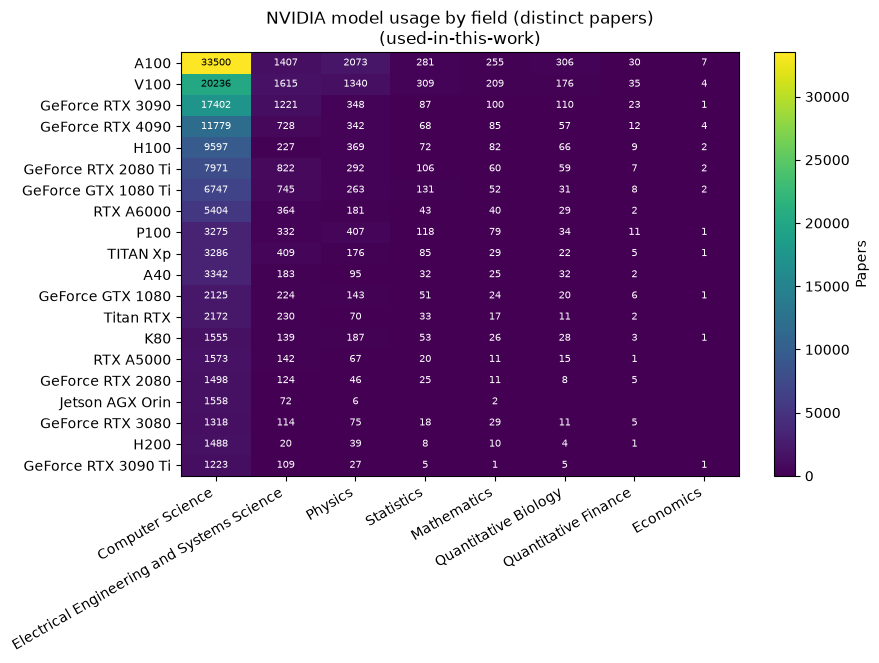

In [7]:
top_models = top_nvidia_models(df)
d = df.filter(pl.col('canonical_display').is_in(top_models) & pl.col('field').is_not_null())
counts = distinct_paper_counts(d, ['canonical_display', 'field'])
top_fields = (counts.group_by('field').agg(t=pl.col('papers').sum())
              .sort('t', descending=True).head(TOP_FIELDS)['field'].to_list())
mat = np.zeros((len(top_models), len(top_fields)))
idx_m = {m: i for i, m in enumerate(top_models)}
idx_f = {f: j for j, f in enumerate(top_fields)}
for r in counts.iter_rows(named=True):
    if r['field'] in idx_f:
        mat[idx_m[r['canonical_display']], idx_f[r['field']]] = r['papers']
fig, ax = plt.subplots(figsize=(9, 5.5))
im = ax.imshow(mat, aspect='auto', cmap='viridis')
ax.set_xticks(range(len(top_fields))); ax.set_xticklabels(top_fields, rotation=30, ha='right')
ax.set_yticks(range(len(top_models)))
ax.set_yticklabels([m.replace('NVIDIA ', '') for m in top_models])
for i in range(len(top_models)):
    for j in range(len(top_fields)):
        if mat[i, j]:
            ax.text(j, i, int(mat[i, j]), ha='center', va='center',
                    color='white' if mat[i, j] < mat.max()*0.6 else 'black', fontsize=7)
ax.set_title(f'NVIDIA model usage by field (distinct papers)\n({USAGE_LABEL})')
fig.colorbar(im, ax=ax, label='Papers'); plt.show()